In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats
import pandas as pd

Критерий согласия Пирсона

In [2]:
def pearson_test(data, dist_name, true_params, false_params):
    n = len(data)

    hist, bin_edges = np.histogram(data, bins=10, density=False)
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
    
    if dist_name == 'norm':
        cdf_true = stats.norm.cdf(bin_edges, *true_params)
    elif dist_name == 'expon':
        cdf_true = stats.expon.cdf(bin_edges, *true_params)
    
    theor_tr = n * np.diff(cdf_true)
    
    if false_params[0] == 'norm':
        cdf_false = stats.norm.cdf(bin_edges, *false_params[1:])
    elif false_params[0] == 'expon':
        cdf_false = stats.expon.cdf(bin_edges, *false_params[1:])
    
    theor_fl = n * np.diff(cdf_false)
    
    mask_true = (theor_tr > 0) & (hist > 0)
    mask_false = (theor_fl > 0) & (hist > 0)
    
    if np.sum(mask_true) <= len(true_params) + 1:
        chi2_true = np.inf
        p_value_true = 0.0
        df_true = 0
    else:
        chi2_true = np.sum(((hist[mask_true] - theor_tr[mask_true])**2) / theor_tr[mask_true])
        df_true = np.sum(mask_true) - len(true_params) - 1
        p_value_true = 1 - stats.chi2.cdf(chi2_true, df_true) if df_true > 0 else 0.0
    
    if np.sum(mask_false) <= len(false_params[1:]) + 1:
        chi2_false = np.inf
        p_value_false = 0.0
        df_false = 0
    else:
        chi2_false = np.sum(((hist[mask_false] - theor_fl[mask_false])**2) / theor_fl[mask_false])
        df_false = np.sum(mask_false) - len(false_params[1:]) - 1
        p_value_false = 1 - stats.chi2.cdf(chi2_false, df_false) if df_false > 0 else 0.0
    
    return {
        'hist': hist,
        'bin_edges': bin_edges,
        'bin_centers': bin_centers,
        'theor_tr': theor_tr,
        'theor_fl': theor_fl,
        'chi2_true': chi2_true,
        'chi2_false': chi2_false,
        'p_value_true': p_value_true,
        'p_value_false': p_value_false,
        'df_true': df_true,
        'df_false': df_false
    }

АНАМОРФОЗЫ
1. нормальное распределение
2. экспотенциальное распределение

In [3]:
def norm_anam(data):
    sorted_data = np.sort(data)
    n = len(data)
    empirical_probs = (np.arange(n) + 0.5) / n
    theor_quant = stats.norm.ppf(empirical_probs)
    return theor_quant, sorted_data

def exp_anam(data):
    sorted_data = np.sort(data)
    n = len(data)
    empirical_probs = (np.arange(n) + 0.5) / n
    theor_quant = -np.log(1 - empirical_probs)
    return theor_quant, sorted_data

def linreg(x, y):
    slope, intercept, r_value, p_value, std_err = stats.linregress(x, y)
    r_squared = r_value**2
    return slope, intercept, r_squared

Файл 1: μ = 1.427, σ = 10.386


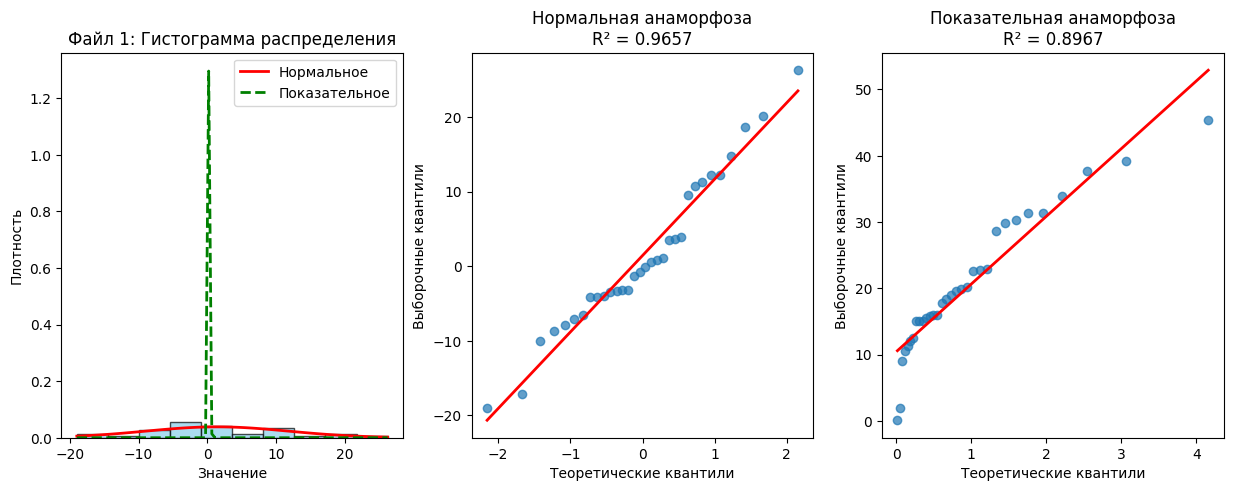

Критерий Пирсона - Нормальное: χ² = 6.965, p-value = 0.432
Критерий Пирсона - Показательное: χ² = inf, p-value = 0.000


In [4]:
data1 = np.loadtxt('1.txt')

mu1 = np.mean(data1)
sigma1 = np.std(data1, ddof=1)
print(f"Файл 1: μ = {mu1:.3f}, σ = {sigma1:.3f}")

result1 = pearson_test(data1, 'norm', [mu1, sigma1], ['expon', 0, 1/np.mean(data1[data1 > 0])])

plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1)
plt.hist(data1, bins=10, density=True, alpha=0.7, color='skyblue', edgecolor='black')
x_range = np.linspace(min(data1), max(data1), 100)
plt.plot(x_range, stats.norm.pdf(x_range, mu1, sigma1), 'r-', linewidth=2, label='Нормальное')
plt.plot(x_range, stats.expon.pdf(x_range, 0, 1/np.mean(data1[data1 > 0])), 'g--', linewidth=2, label='Показательное')
plt.title('Файл 1: Гистограмма распределения')
plt.xlabel('Значение')
plt.ylabel('Плотность')
plt.legend()

plt.subplot(1, 3, 2)
x_norm, y_norm = norm_anam(data1)
slope_norm, intercept_norm, r2_norm = linreg(x_norm, y_norm)
plt.scatter(x_norm, y_norm, alpha=0.7)
plt.plot(x_norm, slope_norm * x_norm + intercept_norm, 'r-', linewidth=2)
plt.title(f'Нормальная анаморфоза\nR² = {r2_norm:.4f}')
plt.xlabel('Теоретические квантили')
plt.ylabel('Выборочные квантили')

plt.subplot(1, 3, 3)
x_exp, y_exp = exp_anam(data1 - min(data1) + 0.1)
slope_exp, intercept_exp, r2_exp = linreg(x_exp, y_exp)
plt.scatter(x_exp, y_exp, alpha=0.7)
plt.plot(x_exp, slope_exp * x_exp + intercept_exp, 'r-', linewidth=2)
plt.title(f'Показательная анаморфоза\nR² = {r2_exp:.4f}')
plt.xlabel('Теоретические квантили')
plt.ylabel('Выборочные квантили')

plt.show()

print(f"Критерий Пирсона - Нормальное: χ² = {result1['chi2_true']:.3f}, p-value = {result1['p_value_true']:.3f}")
print(f"Критерий Пирсона - Показательное: χ² = {result1['chi2_false']:.3f}, p-value = {result1['p_value_false']:.3f}")

Файл 3: λ = 0.189


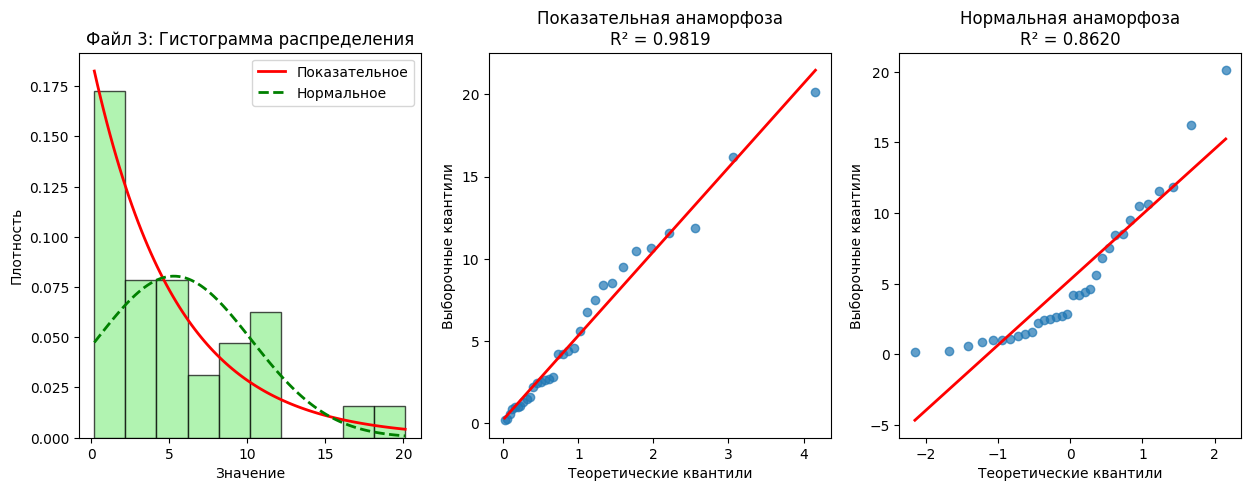

Критерий Пирсона - Показательное: χ² = 7.679, p-value = 0.175
Критерий Пирсона - Нормальное: χ² = 26.272, p-value = 0.000


In [5]:
data3 = np.loadtxt('3.txt')

lambda3 = 1 / np.mean(data3)
print(f"Файл 3: λ = {lambda3:.3f}")

result3 = pearson_test(data3, 'expon', [0, 1/lambda3], ['norm', np.mean(data3), np.std(data3, ddof=1)])

plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1)
plt.hist(data3, bins=10, density=True, alpha=0.7, color='lightgreen', edgecolor='black')
x_range = np.linspace(min(data3), max(data3), 100)
plt.plot(x_range, stats.expon.pdf(x_range, 0, 1/lambda3), 'r-', linewidth=2, label='Показательное')
plt.plot(x_range, stats.norm.pdf(x_range, np.mean(data3), np.std(data3, ddof=1)), 'g--', linewidth=2, label='Нормальное')
plt.title('Файл 3: Гистограмма распределения')
plt.xlabel('Значение')
plt.ylabel('Плотность')
plt.legend()

plt.subplot(1, 3, 2)
x_exp, y_exp = exp_anam(data3)
slope_exp, intercept_exp, r2_exp = linreg(x_exp, y_exp)
plt.scatter(x_exp, y_exp, alpha=0.7)
plt.plot(x_exp, slope_exp * x_exp + intercept_exp, 'r-', linewidth=2)
plt.title(f'Показательная анаморфоза\nR² = {r2_exp:.4f}')
plt.xlabel('Теоретические квантили')
plt.ylabel('Выборочные квантили')

plt.subplot(1, 3, 3)
x_norm, y_norm = norm_anam(data3)
slope_norm, intercept_norm, r2_norm = linreg(x_norm, y_norm)
plt.scatter(x_norm, y_norm, alpha=0.7)
plt.plot(x_norm, slope_norm * x_norm + intercept_norm, 'r-', linewidth=2)
plt.title(f'Нормальная анаморфоза\nR² = {r2_norm:.4f}')
plt.xlabel('Теоретические квантили')
plt.ylabel('Выборочные квантили')

plt.show()

print(f"Критерий Пирсона - Показательное: χ² = {result3['chi2_true']:.3f}, p-value = {result3['p_value_true']:.3f}")
print(f"Критерий Пирсона - Нормальное: χ² = {result3['chi2_false']:.3f}, p-value = {result3['p_value_false']:.3f}")

Файл 4: μ = -0.388, σ = 9.230


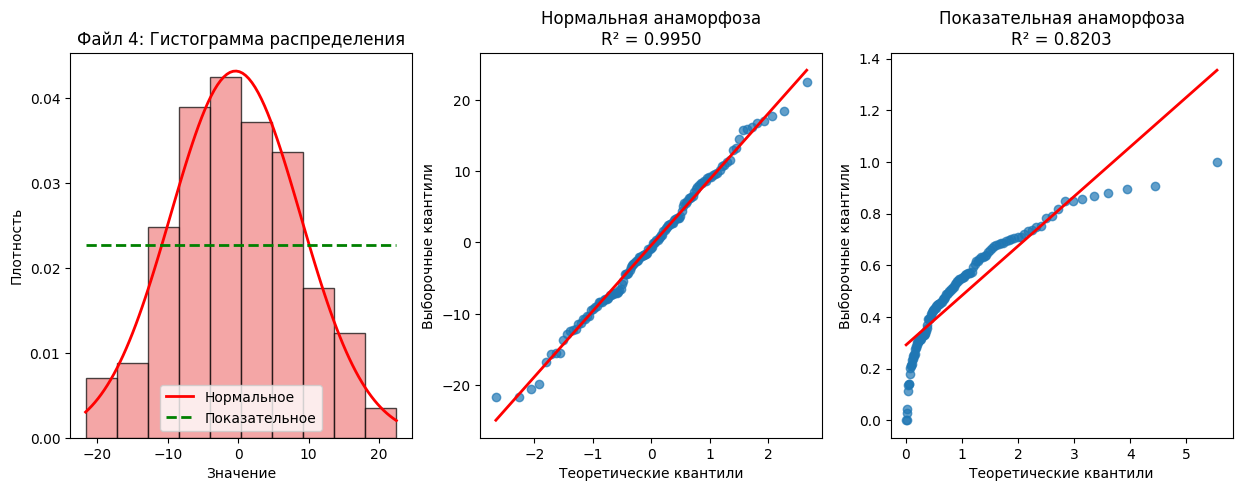

Критерий Пирсона - Нормальное: χ² = 2.085, p-value = 0.955
Критерий Пирсона - Показательное: χ² = 112.313, p-value = 0.000


In [6]:
data4 = np.loadtxt('4.txt')

mu4 = np.mean(data4)
sigma4 = np.std(data4, ddof=1)
print(f"Файл 4: μ = {mu4:.3f}, σ = {sigma4:.3f}")

result4 = pearson_test(data4, 'norm', [mu4, sigma4], ['expon', min(data4), max(data4) - min(data4)])

plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1)
plt.hist(data4, bins=10, density=True, alpha=0.7, color='lightcoral', edgecolor='black')
x_range = np.linspace(min(data4), max(data4), 100)
plt.plot(x_range, stats.norm.pdf(x_range, mu4, sigma4), 'r-', linewidth=2, label='Нормальное')
plt.plot(x_range, stats.uniform.pdf(x_range, min(data4), max(data4) - min(data4)), 'g--', linewidth=2, label='Показательное')
plt.title('Файл 4: Гистограмма распределения')
plt.xlabel('Значение')
plt.ylabel('Плотность')
plt.legend()

plt.subplot(1, 3, 2)
x_norm, y_norm = norm_anam(data4)
slope_norm, intercept_norm, r2_norm = linreg(x_norm, y_norm)
plt.scatter(x_norm, y_norm, alpha=0.7)
plt.plot(x_norm, slope_norm * x_norm + intercept_norm, 'r-', linewidth=2)
plt.title(f'Нормальная анаморфоза\nR² = {r2_norm:.4f}')
plt.xlabel('Теоретические квантили')
plt.ylabel('Выборочные квантили')

plt.subplot(1, 3, 3)
x_uni, y_uni = exp_anam((data4 - min(data4)) / (max(data4) - min(data4)))
slope_uni, intercept_uni, r2_uni = linreg(x_uni, y_uni)
plt.scatter(x_uni, y_uni, alpha=0.7)
plt.plot(x_uni, slope_uni * x_uni + intercept_uni, 'r-', linewidth=2)
plt.title(f'Показательная анаморфоза\nR² = {r2_uni:.4f}')
plt.xlabel('Теоретические квантили')
plt.ylabel('Выборочные квантили')

plt.show()

print(f"Критерий Пирсона - Нормальное: χ² = {result4['chi2_true']:.3f}, p-value = {result4['p_value_true']:.3f}")
print(f"Критерий Пирсона - Показательное: χ² = {result4['chi2_false']:.3f}, p-value = {result4['p_value_false']:.3f}")

Файл 6: λ = 0.526


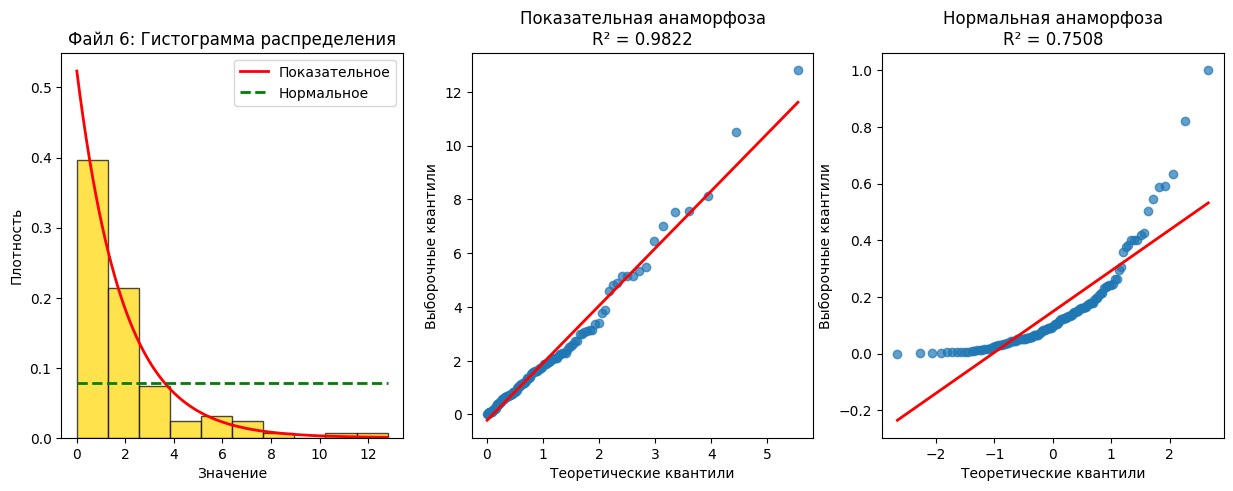

Критерий Пирсона - Показательное: χ² = 12.203, p-value = 0.058
Критерий Пирсона - Нормальное: χ² = 897.640, p-value = 0.000


In [ ]:
data6 = np.loadtxt('6.txt')

lambda6 = 1 / np.mean(data6)
print(f"Файл 6: λ = {lambda6:.3f}")

result6 = pearson_test(data6, 'expon', [0, 1/lambda6], ['norm', min(data6), max(data6) - min(data6)])

plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1)
plt.hist(data6, bins=10, density=True, alpha=0.7, color='gold', edgecolor='black')
x_range = np.linspace(min(data6), max(data6), 100)
plt.plot(x_range, stats.expon.pdf(x_range, 0, 1/lambda6), 'r-', linewidth=2, label='Показательное')
plt.plot(x_range, stats.uniform.pdf(x_range, min(data6), max(data6) - min(data6)), 'g--', linewidth=2, label='Нормальное')
plt.title('Файл 6: Гистограмма распределения')
plt.xlabel('Значение')
plt.ylabel('Плотность')
plt.legend()

plt.subplot(1, 3, 2)
x_exp, y_exp = exp_anam(data6)
slope_exp, intercept_exp, r2_exp = linreg(x_exp, y_exp)
plt.scatter(x_exp, y_exp, alpha=0.7)
plt.plot(x_exp, slope_exp * x_exp + intercept_exp, 'r-', linewidth=2)
plt.title(f'Показательная анаморфоза\nR² = {r2_exp:.4f}')
plt.xlabel('Теоретические квантили')
plt.ylabel('Выборочные квантили')

plt.subplot(1, 3, 3)
x_uni, y_uni = norm_anam((data6 - min(data6)) / (max(data6) - min(data6)))
slope_uni, intercept_uni, r2_uni = linreg(x_uni, y_uni)
plt.scatter(x_uni, y_uni, alpha=0.7)
plt.plot(x_uni, slope_uni * x_uni + intercept_uni, 'r-', linewidth=2)
plt.title(f'Нормальная анаморфоза\nR² = {r2_uni:.4f}')
plt.xlabel('Теоретические квантили')
plt.ylabel('Выборочные квантили')

plt.show()

print(f"Критерий Пирсона - Показательное: χ² = {result6['chi2_true']:.3f}, p-value = {result6['p_value_true']:.3f}")
print(f"Критерий Пирсона - Нормальное: χ² = {result6['chi2_false']:.3f}, p-value = {result6['p_value_false']:.3f}")